What changes from P1 to P2

- Nodes per element:   3             | 6
- Basis functions:     linear        | quadratic
- Gradient:            constant      | linear
- Local matrices:      explformula   | quadrature
- Reference element:   optional      | essential
- Jacobian:            rarely needed | required
- Quadrature:          not necessary | necessary

**Stays the same**:
- mesh generation
- global assembly
- Dirichlet boundary condition
- generalised eigenproblem
- convergence study
- visualisation

**Changes**:
- local basis functions
- local stiffness matrix
- local mass matrix
- element geometry representation
- numerical integration


When to Use which:
Use @ (or np.matmul) for general matrix multiplication (especially 2D or higher-dimensional matrices), as it properly follows mathematical broadcasting rules and is less prone to producing unexpected shapes.
Use np.dot (or np.vdot) for specific linear algebra operations like computing the scalar inner/dot product of two vectors

In [1]:
# 2D let the domain be uniform and defined on [0, 1]x[0, 1]

import numpy as np
import sympy as sp
from scipy.linalg import eigh
from scipy.spatial import Delaunay
import pandas as pd
import math
import matplotlib.pyplot as plt
import pyvista as pv
import os

plt.style.use("seaborn-v0_8-poster")
pv.set_jupyter_backend("html")

**MESH**

In [2]:
### GENERATE NORMAL MESH

def generate_mesh(n_points: int):

       '''
       Generates a 2D mesh over the unit square [0, 1] x [0, 1]

       Places n_points evenly along each axis, builds coordinate grid, 
              and divides into triangulations using Delaunay triangulation
       
       :param n_points: a number of points along each axis
       :return: returns domain - an (N, 2) array of 2D domain coordinates 
              and tri - nodes of the trinagle in the global domain
       '''

       # define the axis intervals
       x = np.linspace(0, 1, n_points)
       y = np.linspace(0, 1, n_points)

       # coordinate generation via meshgrid (takes 1D arrays and duplicates them to build 2D grids)
       X, Y = np.meshgrid(x, y)

       # c_ matches the first X with the first Y, second X with second Y etc
       # ravel() takes 2D matrix structure and reads it row by row into a long single list of coordinates
       # Delaunay cannot read 2D grid, thats why we flatten X and Y, so they can be paired together
       domain = np.c_[X.ravel(), Y.ravel()]
       

       # create triangles on the domain
       tri = Delaunay(domain)

       return domain, tri

In [3]:
### ADD MID POINTS TO THE MESH

def add_mid_pts(domain, triangles_nodes):

       
       mid_pts = {}

       for triangle in triangles_nodes:
              a, b, c = triangle

              edges = [
                     tuple(sorted((a, b))),
                     tuple(sorted((b, c))),
                     tuple(sorted((c, a)))
              ]
       
              for edge in edges:
                     if edge not in mid_pts:
                            i, j = edge

                            midpoint = (domain[i] + domain[j]) / 2
                            mid_pts[edge] = midpoint


       return mid_pts

In [4]:
### GENERATE P2 TRIANGULAR MESH ###

def get_p2_triangles(domain, triangles_nodes, mid_pts):
       

       # assign a unique global index to each midpoint
       # based on sorted edge key, not iteration order
       edge_to_midpoint = {}
       for i, edge in enumerate(sorted(mid_pts.keys())):
              edge_to_midpoint[edge] = len(domain) + i
       
       p2_triangles_nodes = np.zeros((len(triangles_nodes), 6), dtype=int)
       p2_triangles_coords = np.zeros((len(triangles_nodes), 6, 2))

       for i, triangle in enumerate(triangles_nodes):
              # node order: [v0, v1, v2, mid_v0v1, mid_v1v2, mid_v0v2]

              a, b, c = triangle

              mid_ab = edge_to_midpoint[tuple(sorted((a, b)))]
              mid_bc = edge_to_midpoint[tuple(sorted((b, c)))]
              mid_ac = edge_to_midpoint[tuple(sorted((c, a)))]

              p2_triangles_nodes[i, :] = [a, b, c, mid_ab, mid_bc, mid_ac]

              p2_triangles_coords[i, :] = [
                     domain[a],
                     domain[b],
                     domain[c],
                     mid_pts[tuple(sorted((a, b)))],
                     mid_pts[tuple(sorted((b, c)))],
                     mid_pts[tuple(sorted((c, a)))]
              ]


       return p2_triangles_nodes, p2_triangles_coords, edge_to_midpoint

**DERIVATION OF P2 LAGRANGE BASIS FUNCTIONS ON THE REF TRIANGLE**
1) we have to find the basis functions from the reference coordinates and every quadratic polynomial on the ref triangle can be expressed as:

$u(\xi, \eta) = c1 + c2*\xi + c3*\eta + c4*\xi^2 + c5*\xi*\eta + c6*\eta^2$

2) we want to evaluate at every point of the reference triangle with 3 vertices and 3 midpoints of the edges. This gives us a system of parametric equations:
$U = A * c$, where: 
- U = [u1, ..., u6]^T - nodal values, 
- A - Vandermonde matrix,
- c = [c1, ..., c6]^T - polynomial coefficients

3) solving for c will give us the polynomial coefficients in terms of nodal values

4) substituting them back to $u(\xi, \eta)$ will give us:

$u_h = \sum_{i} \phi_{i}(\xi, \eta) * u_i$, where:
- $\phi_i$ are the P2 basis fucntions

**IMPORTANT**
u(xi, eta) = general quadratic polynomial
u_h(xi, eta) = finite element interpolant
phi_i(xi, eta) = basis functions

In [5]:

def u(xi, eta):
       return (c1 + c2*xi + c3*eta + c4*xi**2 + c5*xi*eta + c6*eta**2)


# will treat them as variables and wont raise an udefined error
c1, c2, c3, c4, c5, c6 = sp.symbols("c1 c2 c3 c4 c5 c6")
u1, u2, u3, u4, u5, u6 = sp.symbols("u1 u2 u3 u4 u5 u6")
xi, eta = sp.symbols("xi eta")

def derive_p2_basis_func(show_matrices=False):
       # define ref coords
       ref_pts_coords = [
              (0, 0),
              (1, 0),
              (0, 1),
              (sp.Rational(1, 2), 0),
              (sp.Rational(1, 2), sp.Rational(1, 2)),
              (0, sp.Rational(1, 2))
       ]


       A, U = get_Vand_and_U_matrices(ref_pts_coords)
       if show_matrices == True:
              sp.pprint(U)
              sp.pprint(A)

       # now going other way, to find c1, ..., c2 using u1, ..., u6
       u_h = get_u_h(A)

       # now returning back to find u1, ..., u6 that are expressed in terms ofxi, eta and c1, ..., c6 that are expressed in terms of u1, ..., u6
       basis_functions = [
              sp.simplify(u_h.coeff(ui))
              for ui in [u1, u2, u3, u4, u5, u6]
       ]

       # basis functions matrix

       return sp.Matrix(basis_functions)     



def get_Vand_and_U_matrices(ref_pts_coords):
       # matrix obtained with unknown coef c1, ..., c6
       U = sp.Matrix([
              u(xi, eta)
              for xi, eta in ref_pts_coords
       ])

       # Vandermonde matrix 
       A = sp.Matrix([
              [1, xi, eta, xi**2, xi*eta, eta**2]
              for xi, eta in ref_pts_coords
       ])
       
       return A, U



# approxiate u using the coefficients c1, ..., c6
def get_u_h(A):
       
       # define unknown nodal fucntions
       U_nodal = sp.Matrix([
              u1,
              u2,
              u3,
              u4,
              u5,
              u6
       ])

       A_inv = A.inv()
       c = A_inv * U_nodal

       # approximate the basis function in terms of unknown c1, ..., c6 and ref coords xi and eta
       u_h = (
              c[0] + c[1]*xi + c[2]*eta + c[3]*xi**2 + c[4]*xi*eta + c[5]*eta**2
       )

       return sp.expand(u_h)


**GRADIENTS OF THE BASIS FUNCTIONS**

In [6]:

def basis_func_grad(B_phi):
       xi, eta = sp.symbols("xi eta")

       # for every basis function put the partial derivatives in this matrix
       B_grad_phi = sp.Matrix([
              [sp.diff(phi, xi), sp.diff(phi, eta)]
              for phi in B_phi
       ])
       
       
       return B_grad_phi
       
B_phi = derive_p2_basis_func()
B_grad_phi = basis_func_grad(B_phi)

sp.pprint(B_phi)
sp.pprint(B_grad_phi)


⎡   2                    2          ⎤
⎢2⋅η  + 4⋅η⋅ξ - 3⋅η + 2⋅ξ  - 3⋅ξ + 1⎥
⎢                                   ⎥
⎢            ξ⋅(2⋅ξ - 1)            ⎥
⎢                                   ⎥
⎢            η⋅(2⋅η - 1)            ⎥
⎢                                   ⎥
⎢         4⋅ξ⋅(-η - ξ + 1)          ⎥
⎢                                   ⎥
⎢               4⋅η⋅ξ               ⎥
⎢                                   ⎥
⎣         4⋅η⋅(-η - ξ + 1)          ⎦
⎡4⋅η + 4⋅ξ - 3   4⋅η + 4⋅ξ - 3 ⎤
⎢                              ⎥
⎢   4⋅ξ - 1            0       ⎥
⎢                              ⎥
⎢      0            4⋅η - 1    ⎥
⎢                              ⎥
⎢-4⋅η - 8⋅ξ + 4       -4⋅ξ     ⎥
⎢                              ⎥
⎢     4⋅η             4⋅ξ      ⎥
⎢                              ⎥
⎣     -4⋅η       -8⋅η - 4⋅ξ + 4⎦


**GLOBAL AND LOCAL STIFFNESS AND MASS MATRICES**

In [7]:
### QUADRATURE CONSTANTS ###

def gaussian_quadrature_constants():
       # verified degree-4, 6-point Hammer–Marlowe–Stroud rule
       a1, b1, g1 = 0.816847572980459, 0.091576213509771, 0.109951743655322
       a2, b2, g2 = 0.108103018168070, 0.445948490915965, 0.223381589678011

       quadrature_coords = np.array(
              [
                     [b1, b1],
                     [a1, b1],
                     [b1, a1],
                     [b2, b2],
                     [a2, b2], 
                     [b2, a2]
              ]
       )
       # weights for the 6 point quadrature
       weights = np.array([g1, g1, g1, g2, g2, g2])

       return quadrature_coords, weights

def gaussian_quadrature_constants_deg6():
       # Dunavant (1985) rule, degree 6, 12 points
       # from Burkardt's reference inplementation, rederived from the its barycentric coordinates
       wA, a1, b1 = 0.116786275726379, 0.501426509658179, 0.249286745170910
       wB, a2, b2 = 0.050844906370207, 0.873821971016996, 0.063089014491502
       wC, c1, c2, c3 = 0.082851075618374, 0.053145049844817, 0.310352451033784, 0.636502499121399

       quadrature_coords = np.array([
              [b1, b1], [b1, a1], [a1, b1],
              [b2, b2], [b2, a2], [a2, b2],
              [c2, c3], [c3, c1], [c1, c2],
              [c1, c3], [c2, c1], [c3, c2],
       ])
       weights = np.array([wA, wA, wA, wB, wB, wB, wC, wC, wC, wC, wC, wC])

       return quadrature_coords, weights

In [8]:
### GET LOCAL STIFFNESS AND MASS MATRICES ###

def get_local_matrices(grad_phi_func, phi_func, quadrature_coords,
                            weights, det_J, G, V_q):
       A_e = np.zeros((6, 6))
       M_e = np.zeros((6, 6))
       V_e = np.zeros((6, 6))

       for i, (xi_q, eta_q) in enumerate(quadrature_coords):
              
              # evaluate gradients at the reference coordinates and put them into numpy matrix
              B = np.array(grad_phi_func(xi_q, eta_q), dtype=float)
              # check if the column sum is zero
              assert np.allclose(B.sum(axis=0), 0)

              # get local stiffness matrix
              A_e += (weights[i] / 2) * det_J * B @ G @ B.T

              # evaluate basis functions at the reference coordinates and put them into numpy matrix
              phi_q = np.array(phi_func(xi_q, eta_q), dtype=float)
              # get local mass matrix
              M_e += (weights[i] / 2) * det_J * np.outer(phi_q, phi_q)

              # get local potential matrix
              V_e += (weights[i] / 2) * V_q[i] * det_J * np.outer(phi_q, phi_q)

       # check if the matrix is symmetric
       assert np.allclose(A_e, A_e.T)
       assert np.allclose(A_e.sum(axis=1), 0)

       assert np.allclose(M_e, M_e.T)
       assert np.allclose(V_e, V_e.T)

       return A_e, M_e, V_e
       

In [9]:
### ASSEMBLY OF THE GLOBAL MATRICES ###

# put the triangle in the global matrix
def put_local_to_global(global_matrix, local_matrix, nodes):

       '''
       This method puts local matrices into the corresponding global ones according to their position in the domain

       :param global_matrix: the global matrix (the matrix of the domain) either empty if the first node or already have previous local matrices in it
       :param local_matrix: the matrix of the triangle
       :param coord: the coordinates of the triangle in the domain

       :return: return the obtained global matrix
       '''

       n_local = local_matrix.shape[0]

       # we need to put every value of the local matrix to the global, that's why we need 2 loops: one for rows, another for columns
       for a in range(n_local):
              for b in range(n_local):
                     global_matrix[nodes[a], nodes[b]] += local_matrix[a, b]
       

       return global_matrix

# Assemble
def compute_global_matrices(p2_triangles_coords, p2_triangles_nodes, 
                            quadrature_coords, weights, grad_phi_func, phi_func, potential):
       

       n_nodes = int(p2_triangles_nodes.max()) + 1  
       A_global = np.zeros((n_nodes, n_nodes), dtype=float)
       M_global = np.zeros((n_nodes, n_nodes), dtype=float) 
       V_global = np.zeros((n_nodes, n_nodes), dtype=float)
          
       xi, eta = quadrature_coords[:, 0], quadrature_coords[:, 1]
       # for every triangle
       for triangle, nodes in zip(p2_triangles_coords, p2_triangles_nodes):
              x1, y1 = triangle[0] # vertex 1
              x2, y2 = triangle[1] # vertex 2
              x3, y3 = triangle[2] # vertex 3

              # Jacobian matrix
              J = np.array(
                     [
                            [x2 - x1, x3 - x1],
                            [y2 - y1, y3 - y1]
                     ]
              )
              det_J = abs(np.linalg.det(J))

              # Metric tensor
              G = np.linalg.inv(J) @ np.linalg.inv(J).T

              # physical location of every quadrature point in this triangle
              x_phys = x1 + xi * (x2 - x1) + eta * (x3 - x1)
              y_phys = y1 + xi * (y2 - y1) + eta * (y3 - y1)

              # callable checks if the potential is a method, it will allow to use this variable both as constant for Laplace (v=0), 
              # simple Schrodinger (v=const) and some special cases of Schrodinger, where we will have to define v as a function, for example in harmonic oscillator
              if callable(potential):
                     V_q = potential(x_phys, y_phys)
              else:
                     V_q = np.full(len(xi), potential)
              
              # local matrices
              A_e, M_e, V_e = get_local_matrices(grad_phi_func, phi_func, quadrature_coords, weights, det_J, G, V_q)

              # assembly
              A_global = put_local_to_global(A_global, A_e, nodes)
              M_global = put_local_to_global(M_global, M_e, nodes)
              V_global = put_local_to_global(V_global, V_e, nodes)

       # checks
       assert np.allclose(A_global.sum(axis=1), 0)
       assert np.allclose(A_global, A_global.T)
       assert np.allclose(M_global, M_global.T)
       assert np.allclose(V_global, V_global.T)
       
       return A_global, M_global, V_global
              



**DIRICHLET BOUNDARY CONDITION**

In [10]:
### BOUNDARY AND INTERIOR NODES; DIRICHLET BOUNDARY CONDITION ###

def get_boundary_and_interior_nodes(all_nodes_coords):

       '''
       Classifies every global P2 node (vertices + edge midpoints) as
       interior or boundary, based on whether it lies on x=0, x=1, y=0, or y=1.
       Global index ordering matches get_p2_triangles: 0..len(domain)-1 are
       vertices, len(domain).. are midpoints in mid_pts insertion order.
    
       '''

       interior_nodes = []
       boundary_nodes = []

       # get the node and its coordinates
       for i, (x, y) in enumerate(all_nodes_coords):
              on_boundary = (
                     np.isclose(x, 0) or np.isclose(x, 1) or
                     np.isclose(y, 0) or np.isclose(y, 1)
              )

              # check if any of the coordinates are on the boundary
              if on_boundary:
                     boundary_nodes.append(i)
              else:
                     interior_nodes.append(i)

       return {
              "interior": {"nodes": interior_nodes, "coords": all_nodes_coords[interior_nodes]}, 
              "boundary": {"nodes": boundary_nodes, "coords": all_nodes_coords[boundary_nodes]}}


def apply_dirichlet(global_matrix, interior_nodes):

       '''
       apply_dirichlet is the method that reduces the global matrices according to the Dirichet Boundary Condition
              all the nodes on the boundary will be excluded from the global matrices because they will be zero

       :param global_matrix: global matrix
       :param interior_nodes: the list of the interior nodes

       :return: returns the reduced global martix based on the interior nodes of the domain
       '''

       # reducing matrices based on boundary condition, that u = 0 on the boundary
       reduced_matrix = global_matrix[np.ix_(interior_nodes, interior_nodes)]
       

       return reduced_matrix

**EIGENVALUES ERRORS**

In [11]:
### EXACT EIGENVALUES AND MODES ###

# m - number of half sine waves in the x-direction
# n - number of half sine waves in the y-direction
# the exact eigenfunction is sin(m*pi*x)*sin(n*pi*y)
def exact_eigenvalue(m, n, potential=0):
       return np.pi**2 * (m**2 + n**2) + potential

def get_sorted_modes(max_m=5, max_n=5):
       """
       Generate (m,n) pairs sorted by exact eigenvalue, grouping the repeated once
       """

       # the flat list of every possible pair up to max_m and max_n
       modes = []
       for m in range(1, max_m+1):
              for n in range(1, max_n+1):
                     modes.append((m, n))
       
       # sort by eigenvalue
       # *mn i scalled unpacking - it takes a tuple and spreads it into separate arguments
       modes.sort(key=lambda mn: exact_eigenvalue(*mn))
       return modes

In [12]:
### EIGENVALUES ERRORS ###

def eigenvalues_info(eigvals, potential=0):
       modes = get_sorted_modes()
       eigvals_info = []

       i = 0 # index into eigvals
       j = 0 # index into modes

       while i < len(eigvals) and j < len(modes):
              m, n = modes[j]
              exact_eigval = exact_eigenvalue(m, n, potential=potential)

              # check if next mode is degenerate (repeted, i.e same exact eigenvalue)
              if j+1 < len(modes) and np.isclose(exact_eigenvalue(*modes[j+1]), exact_eigval):
                     m2, n2 = modes[j+1]

                     # this eigenvalue is repeated - consumes two numerical eigenvalues
                     if i+1 < len(eigvals):
                            error1 = abs(eigvals[i] - exact_eigval)
                            error2 = abs(eigvals[i+1] - exact_eigval)

                            info = {
                                   "rank": f"{i+1} & {i+2}",
                                   "(m,n) pair": f"{(m, n)} & {(m2, n2)}",
                                   "exact": round(exact_eigval, 6),
                                   "numerical": [round(eigvals[i], 6), round(eigvals[i+1], 6)],
                                   "error": [round(error1, 6), round(error2, 6)]
                            }
                            eigvals_info.append(info)

                            i += 2
                            j += 2

                     else:
                            break
                     
              else:
                     # simple (non-repeated) eigenvalue
                     error = abs(eigvals[i] - exact_eigval)
                     info = {
                            "rank": f"{i+1}",
                            "(m,n) pair": str((m, n)),
                            "exact": round(exact_eigval, 6),
                            "numerical": round(eigvals[i], 6),
                            "error": round(error, 6)
                     }
                     eigvals_info.append(info)

                     i += 1
                     j += 1

       return eigvals_info


**EIGENFUNCTIONS ERRORS**
The continuous L2 norm is:

$∥u∥L2=∫Ωu2 dx\|u\|_{L^2} = \sqrt{\int_\Omega u^2 \, dx}∥u∥L2​=∫Ω​u2dx​$

The discrete Euclidean norm is:

$∥uh∥ℓ2=∑iui2\|u_h\|_{\ell^2} = \sqrt{\sum_i u_i^2}∥uh​∥ℓ2​=i∑​ui2​​$

These differ by a factor of $hd\sqrt{h^d}$, where h is the mesh spacing and d is the dimension. 
So as you refine your mesh, the Euclidean norm systematically shrinks relative to the true L2 norm, and your measured convergence rate will be polluted by this mesh-dependent scaling artifact — not just your FEM error.
What you need instead is the mass-matrix weighted norm:
$∥uh∥L2≈uhTMuh\|u_h\|_{L^2} \approx \sqrt{u_h^T M u_h}∥uh​∥L2​≈uhT​Muh​​$

In [13]:
# global symbols not to cause the error in the exact_eigenfunction and not to be overwritten in the loops
x_sym, y_sym = sp.symbols("x y")

In [14]:
### EXACT EIGENFUNCTION AND NORMALISATION ###
import functools

# M_norm
def m_norm(v, M):
       return np.sqrt(v @ M @ v)

def exact_eigenfunction(m, n):
       
       return sp.sin(m * sp.pi * x_sym) * sp.sin(n * sp.pi * y_sym)

       
# means numpy_exact_fn(1, 1) only calls sympy once ever, regardless of how many times it's called across mesh refinements. 
@functools.lru_cache(maxsize=None) 
def numpy_exact_fn(m, n):
       return sp.lambdify((x_sym, y_sym), exact_eigenfunction(m, n), "numpy")

@functools.lru_cache(maxsize=None)
def numpy_grad_fns(m, n):
       du_dx = sp.lambdify((x_sym, y_sym), sp.diff(exact_eigenfunction(m, n), x_sym), "numpy")
       du_dy = sp.lambdify((x_sym, y_sym), sp.diff(exact_eigenfunction(m, n), y_sym), "numpy")
       
       return du_dx, du_dy

def sign_check(u_h_norm, M, exact_eigf_norm):
       return -u_h_norm if u_h_norm @ M @ exact_eigf_norm < 0 else u_h_norm

def evaluate_exact_eigf(xs, ys, m, n, M):

       # exact basis vectors for the 2D eigenspace
       exact_eigf = numpy_exact_fn(m, n)(xs, ys)
       norm = m_norm(exact_eigf, M)

       # normalise
       exact_eigf_norm = exact_eigf / norm
       
       
       return exact_eigf_norm, norm


In [15]:
### EIGFUNCTIONS ERRORS ###
def eigfs_info(eigvecs, node_coords, M):


       modes = get_sorted_modes() # because sorting by eigenvalues, not eigenfunctions
       results = []

       # all node coords as array
       xs = node_coords[:, 0]
       ys = node_coords[:, 1]

       n_vecs = eigvecs.shape[0] # eigvecs.T passed in, so rows are eigenvectors


       for i, (m, n) in enumerate(modes[:len(eigvecs)]):

              exact_eigf_norm, _ = evaluate_exact_eigf(xs, ys, m, n, M)


              # find best matching eigenvector by M projection
              # compute all projections at once using matrix operations
              # eigvecs is (n_vecs, n_dofs), so eigvecs @ M gives (n_vecs, n_dofs)
              # then dot with exact_eigf_norm gives (n_vecs,) - all projections at once
              M_exact = M @ exact_eigf_norm # (n_dofs,)
              projections = np.abs(eigvecs @ M_exact) # (n_vecs,)
              best_k = int(np.argmax(projections))
              # use copy to have an independent, not to cause bugs in the future, because all the changes will apply to the array
              u_h = eigvecs[best_k].copy()
       
              
              #print(f"mode ({m}, {n}), eigvec {best_k}: |<u_h, f_exact>|_M = {projections[best_k]:.6f}")
              
              # normalise with M norm
              u_h_norm = u_h / m_norm(u_h, M)

              # sign handling, needs to be done after normalising
              u_h_norm = sign_check(u_h_norm, M, exact_eigf_norm)


              # error in M norm
              error = m_norm(exact_eigf_norm - u_h_norm, M)
              
              results.append({
                     "(m,n)": (m, n),
                     "mathced_eigvec": best_k,
                     "exact eigf": exact_eigf_norm,
                     "computed eigf": u_h_norm,
                     "error": error
              })
       # the error might look large, but it will happen not because the calculations were wrong, but because the solver picked a rotated basis

       return results      


**DEGENERATE EIGENFUNCTIONS ERRORS**

the H1 error is:
$∥u_h−u∥_{H^1} = \sqrt{\|u_h - u\|_{L^2}^2 + \|\nabla u_h - \nabla u\|_{L^2}^2}$


In [16]:
### DEGENERATE PAIR ### 

def find_degenerate_pair(eigvals, target_eigval):
       """
       find the indices of the pair closest to the target eigval
       """
       tol = 0.1 * target_eigval
       diffs = np.abs(eigvals - target_eigval)
       # get indices sorted by closeness
       sorted_indx = np.argsort(diffs)
       i, j =  int(sorted_indx[0]), int(sorted_indx[1])

       if diffs[i] > tol:
              raise ValueError(f"No degenerate pair found near {target_eigval:.4f}. "
                                   f"Closest eigenvalue: {eigvals[i]:.4f} at index {i}")

       return i, j

In [17]:
### L2 DEGENERATE EIGENFUNCTIONS ERRORS ###
    
def eigenspace_degenerates_errors(eigvecs, M, p2_triangles_coords, p2_triangles_nodes,
                                   grad_phi_func, phi_func, quadrature_coords,
                                   weights, modes, interior_nodes, total_nodes, node_coords, i, j, proj=True):
       """
       For a degenerate pair: check that both numerical eigenvectors lie inside the exact 2D eigenspace, regardless of rotation angle
       """

       xs = node_coords[:, 0]
       ys = node_coords[:, 1]

       m1, n1 = modes[1]
       m2, n2 = modes[2]

       # normalise
       f1_norm, _ = evaluate_exact_eigf(xs, ys, m1, n1, M)
       f2_norm, _ = evaluate_exact_eigf(xs, ys, m2, n2, M)

       #print(f"eigval[1] = {eigvals[1]:.6f}, eigval[2] = {eigvals[2]:.6f}, exact = {5 * np.pi**2:.6f}")

       errors = []
       coefs = {"alphas": [], "betas": []}
       for k in [i, j]:
              u_h = eigvecs[:, k].copy() 
              u_h_norm = u_h / m_norm(u_h, M)

              # project u_h onto the exact eigensspace
              # alpha and beta are the rotations
              # it works because f1 and f2 are orthonormal
              alpha = u_h_norm @ M @ f1_norm
              beta = u_h_norm @ M @ f2_norm
              P_u_h = alpha * f1_norm + beta * f2_norm

              # will need them for the visualisations
              coefs["alphas"].append(alpha)
              coefs["betas"].append(beta)

              # error = how much of u_h lies outside the eigenspace
              if proj:
                     error = m_norm(u_h_norm - P_u_h, M)
                     errors.append(error)
                     
              else:
                     error = H1_error(
                            u_h_norm, M, p2_triangles_coords, p2_triangles_nodes, grad_phi_func, phi_func,
                            quadrature_coords, weights, interior_nodes, total_nodes, node_coords, 
                            modes, degenerate=True, alpha=alpha, beta=beta
                     )
                     errors.append(error)

       # some checks that were done to find the bugs
       #print("M-inner product f1,f2:", f1 @ M @ f2)  # should be ~0 if M-orthogonal
       #print("|<u1, f1>|:", abs(eigvecs[:,1] @ M @ f1))
       #print("|<u1, f2>|:", abs(eigvecs[:,1] @ M @ f2))
       if proj:
              return errors, coefs
       else:
              return errors



In [18]:
### H1 EIGENFUNCTION ERRORS ###
def H1_error(eigvec, M, p2_triangles_coords, p2_triangles_nodes, grad_phi_func, phi_func, 
              quadrature_coords, weights, interior_nodes, total_nodes, node_coords, modes,
              degenerate = False, alpha = None, beta = None
              ):

       xs = node_coords[:, 0]
       ys = node_coords[:, 1]
       
       # case for 1st eigenvector
       if not degenerate:
              eigvec = eigvec.copy()
              m, n = modes[0]

              # exact gradient
              du_dx_fn, du_dy_fn = numpy_grad_fns(m, n)
              
              u_exact_fn = numpy_exact_fn(m, n)
              u_exact_norm, normalisation = evaluate_exact_eigf(xs, ys, m, n, M)


              eigvec_norm = eigvec / m_norm(eigvec, M)    

       
       else:
              eigvec = eigvec.copy()
              m1, n1 = modes[1]
              m2, n2 = modes[2]

              du_dx_f1, du_dy_f1 = numpy_grad_fns(m1, n1)
              du_dx_f2, du_dy_f2 = numpy_grad_fns(m2, n2)
              

              f1_vals, norm_f1 = evaluate_exact_eigf(xs, ys, m1, n1, M)
              f2_vals, norm_f2 = evaluate_exact_eigf(xs, ys, m2, n2, M)
              

              alpha_raw = alpha / norm_f1
              beta_raw = beta / norm_f2

              f1_fn = numpy_exact_fn(m1, n1)
              f2_fn = numpy_exact_fn(m2, n2)

              u_exact_fn = lambda x, y: alpha_raw * f1_fn(x, y) + beta_raw * f2_fn(x, y)
              du_dx_fn = lambda x, y: alpha_raw * du_dx_f1(x, y) + beta_raw * du_dx_f2(x, y)
              du_dy_fn = lambda x, y: alpha_raw * du_dy_f1(x, y) + beta_raw * du_dy_f2(x, y)


              # normalisation constant 
              normalisation = 1.0

              u_exact = u_exact_fn(xs, ys)
              # normalise
              u_exact_norm = u_exact / normalisation

              # here eigvec doestn need normalisation as it arrives normalised
              eigvec_norm = eigvec

              
       # sign handling
       eigvec_norm = sign_check(eigvec_norm, M, u_exact_norm)
       
       
       eigvec_full = np.zeros(total_nodes)
       eigvec_full[interior_nodes] = eigvec

       L2_sq = 0.0
       H1_sq = 0.0

       # for every triangle
       for triangle, nodes in zip(p2_triangles_coords, p2_triangles_nodes):
              x0, y0 = triangle[0] # vertex 1
              x1, y1 = triangle[1] # vertex 2
              x2, y2 = triangle[2] # vertex 3

              # DOF values at the 6 nodes
              u_nodes = eigvec_full[nodes] # (6, )
              

              # Jacobian matrix
              J = np.array(
                     [
                            [x1 - x0, x2 - x0],
                            [y1 - y0, y2 - y0]
                     ]
              )
              
              det_J = abs(np.linalg.det(J))
              inv_J = np.linalg.inv(J)
              

              for i, (xi_q, eta_q) in enumerate(quadrature_coords):
              
                     # evaluate basis functions at the reference coordinates and put them into numpy matrix
                     phi_q = np.array(phi_func(xi_q, eta_q), dtype=float).flatten() # (6,)
                     
                     # evaluate gradients at the reference coordinates and put them into numpy matrix
                     grad_phi_q = np.array(grad_phi_func(xi_q, eta_q), dtype=float) # (6,2)
                    
                     # physical coords of the quadrature point
                     x_q = x0 + (x1 - x0) * xi_q + (x2 - x0) * eta_q
                     y_q = y0 + (y1 - y0) * xi_q + (y2 - y0) * eta_q

                     ## L2
                     # interpolated u_h at quadrature points
                     u_h_q = phi_q @ u_nodes

                     u_ex_q = u_exact_fn(x_q, y_q) / normalisation

                     # need to divide by 2 because the quadrature weights are summed to 1, so they are for the unit square, not the triangle
                     L2_sq += weights[i] * 0.5 * abs(det_J) * (u_h_q - u_ex_q)**2

                     ## H1
                     # gradient on the reference trinagle
                     grad_ref = grad_phi_q.T @ u_nodes # (2, ) gradient in ref coords
                     # map to physical gradient
                     grad_phys = inv_J.T @ grad_ref # (2, ) gradient in physical coords


                     diff_x = grad_phys[0] - du_dx_fn(x_q, y_q) / normalisation
                     diff_y = grad_phys[1] - du_dy_fn(x_q, y_q) / normalisation
                     H1_sq += weights[i] * 0.5 * abs(det_J) * (diff_x**2 + diff_y**2)

       # for P2 elements should expect the convergence rate of O(h^2)
       return np.sqrt(L2_sq + H1_sq)
       



**CONVERGENCE STUDY**

In [19]:
### local convergence rate ###

def local_convergence_rate(row_num, n_points_list, errors):
       
       '''
       This method finds the local convergence rate (between two neighbouring rates), 
       which in other words means "how fast are we approaching the exact value"

       :param row_num: detects where are we in the table of convergence
       :param n_points_list: list of numbers of points, 
       we will need them to find the ratio between the number of points because it will determine the convergence rate
       :param errors: a list of errors that we got from comparing the exact value with numerical

       :return: returns the local rate of convergence or
       None if it is the first row or if the error is 0 or negative to ensure that we won't face division by nothing or zero
       '''

       if row_num == 0:
              
              return np.nan
              
       # prevents the cases when the error is 0
       e_old = errors[row_num-1]
       e_new = errors[row_num]
       if e_old <= 0 or e_new <= 0:
              return np.nan

       # find the local convergence rate

       # we need to find the base for the logarithm first
       ratio_between_num_points = n_points_list[row_num] / n_points_list[row_num-1] 
       # find the ratio between 2 neighbouring local errors
       ratio_between_errors = errors[row_num-1] / errors[row_num]
       # calculate the local rate of convergence
       p_local = math.log(ratio_between_errors, ratio_between_num_points)

       return p_local



**VISUALISATIONS**

In [20]:
### VISUALISE MESH ###
def visualise_mesh(all_nodes_coords, triangle):

       '''
       visualise_mesh will help to see the location of the nodes and local triangles

       :param all_nodes_coords: the list of coordinates of all nodes
       :param triangle: the list of coordinates of the nodes of the local triangle
       '''
       
       plt.triplot(all_nodes_coords[:,0], all_nodes_coords[:,1], triangle.simplices.copy())
       plt.plot(all_nodes_coords[:,0], all_nodes_coords[:,1], "o")

       # to see the nodes on the graph
       # enumerate shows which node number corresponds to the coordinates
       for i, (x, y) in enumerate(all_nodes_coords):
              plt.text(x, y, f"P{i}", fontsize=9)

       # labeling the triangles
       for k, tri in enumerate(triangle.simplices):

              centroid = all_nodes_coords[tri].mean(axis=0)

              plt.text(centroid[0], centroid[1], f"T{k}", color="red", fontsize=6)

       # gca - get current axes
       plt.gca().set_title("Mesh visualisation")
       
       # set_aspect("equal") prevents stretching the plot, if it's square it will look like square
       plt.gca().set_aspect("equal")
       plt.show()

Surface plots of the FEM functions

We need to subdivide our p2 triangles so the visualisation will show the correct geomentry and true quadratic solution

- Mode 1 — [Certain] this is correct behaviour. The first Laplacian eigenfunction on any convex domain is strictly positive, has no zero crossings interior to the domain, and peaks at roughly the "centre of mass" of the domain. Your plot shows exactly that: one smooth hump, all positive values (colorbar 0 to 2.03), zero on the boundary.
- Mode 2 — [Certain] this is also correct in structure. Higher modes must be orthogonal to Mode 1, which forces sign changes. You can see the positive spike and the negative trough (colorbar −2.01 to +2.01), separated by a nodal line where u=0. The shape of that nodal line tells you about the geometry's symmetry.

In [21]:
### SURFACE PLOTS OF EIGENFUNCTIONS ###

def subdivide_p2_mesh(p2_triangles):
       vis_triangles = []
       for triangle in p2_triangles:
              v1, v2, v3, m12, m23, m31 = triangle

              vis_triangles.extend(
                     [
                            [v1, m12, m31],
                            [v2, m23, m12],
                            [v3, m31, m23],
                            [m12, m23, m31]
                     ]
              )
       return np.array(vis_triangles)

def build_connectivity(vis_triangles):

       cells = []

       for triangle in vis_triangles:
              cells.extend([3, *triangle])

       cells = np.array(cells)

       celltypes = np.full(
              len(vis_triangles),
              pv.CellType.TRIANGLE
       )

       return cells, celltypes

def build_mesh(all_nodes_coords, u_vals, cells, celltypes, label):

       # 3D coordinates
       points = np.column_stack(
                     [
                            all_nodes_coords[:, 0],
                            all_nodes_coords[:, 1],
                            u_vals
                     ]
              )
       
       mesh = pv.UnstructuredGrid(
                     cells, 
                     celltypes,
                     points
              )

       mesh[label] = u_vals

       return mesh
       


def visualise_surface_plots_of_FEM(eigvecs, all_nodes_coords, vis_triangles, n_nodes, interior_nodes):

       '''
       This method visualises the numerical functions that were found using finite element method

       :param eigenvectors: the coordinates of the eigenvector that were obtained numerically
       :param all_nodes_coords: the list of coordinates of all nodes
       :param n_nodes: number of the nodes
       :param interior_nodes: the list of the interior nodes (that are not on the boundary)
       '''

       n_modes = min(3, eigvecs.shape[1])
       ### connectivity
       cells, celltypes = build_connectivity(vis_triangles)

       plotter = pv.Plotter(shape=(1, n_modes), notebook=True)

       for mode in range(n_modes):

              # full solution including boundary nodes
              u = np.zeros(n_nodes)
              u[interior_nodes] = eigvecs[:, mode]

              peak_index = np.argmax(np.abs(u[interior_nodes]))
              if u[interior_nodes][peak_index] < 0:
                     u *= -1

              label = f"Eigenfunction {mode+1}"

              ### mesh
              mesh = build_mesh(
                     all_nodes_coords,
                     u,
                     cells,
                     celltypes,
                     label

              )

              plotter.subplot(0, mode)
              plotter.add_mesh(
                     mesh,
                     scalars=label,
                     cmap="viridis",
                     show_edges=True,
                     scalar_bar_args={"title": label}
              )
              
              plotter.add_text(
                     f"Mode {mode+1}",
                     position="upper_edge",
                     font_size=12,
                     name=f"mode_title_{mode}"
              )

       plotter.show()
       plotter.close()

def save_eigenfunction_pngs(
       eigvecs, all_nodes_coords, vis_triangles, n_nodes, interior_nodes,
       n_modes=3, output_dir=".", basename="eigenfunction",
       window_size=(1200, 900), scale=2, shared_clim=True
):
       assert eigvecs.shape[1] >= n_modes, (
              f"Requested {n_modes} modes but eigvecs only has {eigvecs.shape[1]} columns"
       )
       os.makedirs(output_dir, exist_ok=True)
       cells, celltypes = build_connectivity(vis_triangles)

       
       for mode in range(n_modes):
              u = np.zeros(n_nodes)
              u[interior_nodes] = eigvecs[:, mode]
              peak_index = np.argmax(np.abs(u[interior_nodes]))

              if u[interior_nodes][peak_index] < 0:
                     u *= -1
              
              label = f"Eigenfunction {mode + 1}"
              mesh = build_mesh(all_nodes_coords, u, cells, celltypes, label)

              plotter = pv.Plotter(off_screen=True, window_size=window_size)
              plotter.add_mesh(
                     mesh,
                     scalars=label,
                     cmap="coolwarm",
                     show_edges=True,
                     scalar_bar_args={"title": label},
              )
              plotter.add_text(f"Mode {mode + 1}", position="upper_edge", font_size=12)

              out_path = os.path.join(output_dir, f"{basename}_mode{mode + 1}.png")
              plotter.screenshot(out_path, scale=scale)
              plotter.close()
              print(f"Saved {out_path}")
 


Exact vs Numerical 

[Certain] The error plot (right panel) is the most informative one. Specifically:

- Peaks near boundary → your boundary condition enforcement has a problem
- Peaks near triangle corners → mesh is too coarse, refine there
- Uniform small error everywhere → your FEM is working correctly, error is just discretisation noise that shrinks as you refine

In [22]:
### EXACT VS NUMERICAL ###


def visualise_exact_vs_numerical(
       eigvecs, modes, all_nodes_coords, vis_triangles, n_nodes, interior_nodes, M,
       mode=0, alpha=None, beta=None, degenerate=False):
       
       xs = all_nodes_coords[:, 0]
       ys = all_nodes_coords[:, 1]

       # numerical
       u_h = np.zeros(n_nodes)
       u_h[interior_nodes] = eigvecs[:, mode]
       u_h_interior = eigvecs[:, mode].copy()
       u_h_norm_interior = u_h_interior / m_norm(u_h_interior, M)
       # fix the sign
       peak_index = np.argmax(np.abs(u_h_norm_interior))
       if u_h_norm_interior[peak_index] < 0:
              u_h_norm_interior *= -1

       u_h[interior_nodes] = u_h_norm_interior

       if not degenerate:
              m, n = modes[0]
              f_norm, _ = evaluate_exact_eigf(
                     all_nodes_coords[interior_nodes, 0],
                     all_nodes_coords[interior_nodes, 1], 
                     m, n, M
              )
              # signed pointwise error field
              error_interior = u_h_norm_interior - f_norm

              u_exact_full = np.zeros(n_nodes)
              u_exact_full[interior_nodes] = f_norm

       
       else:
              # will use the projection that already computed
              m1, n1 = modes[1]
              m2, n2 = modes[2]

              f1_norm, _ = evaluate_exact_eigf(
                     all_nodes_coords[interior_nodes, 0],
                     all_nodes_coords[interior_nodes, 1], 
                     m1, n1, M
              )
              f2_norm, _ = evaluate_exact_eigf(
                     all_nodes_coords[interior_nodes, 0],
                     all_nodes_coords[interior_nodes, 1], 
                     m2, n2, M
              )

              
              P_u_h = alpha * f1_norm + beta * f2_norm

              # match sign of P_u_h to u_h_norm_interior
              # We're checking whether the two functions have the same sign at the dominant node — 
              # if the product is negative they disagree, so flip P_u_h. This is more robust than checking P_u_h's own peak independently.
              peak_index = np.argmax(np.abs(u_h_norm_interior))
              if P_u_h[peak_index] * u_h_norm_interior[peak_index] < 0:
                     P_u_h *= -1

              # signed pointwise error - what lies outside the eigenspace
              error_interior = u_h_norm_interior - P_u_h

              u_exact_full = np.zeros(n_nodes)
              u_exact_full[interior_nodes] = P_u_h
       

       u_error_full = np.zeros(n_nodes)
       u_error_full[interior_nodes] = error_interior

       if degenerate:
              print(f"Degenerate mode {mode}: alpha={alpha:.4f}, beta={beta:.4f} - numerical eigenvector is a rotation within the exact eigenspace.")
       


       # build connectivity
       cells, celltypes = build_connectivity(vis_triangles)

       # meshes
       mesh_num = build_mesh(
              all_nodes_coords,
              u_h,
              cells,
              celltypes,
              "Numerical"
       )

       mesh_exact = build_mesh(
              all_nodes_coords,
              u_exact_full,
              cells,
              celltypes,
              "Exact"
       )

       mesh_error = build_mesh(
              all_nodes_coords,
              u_error_full,
              cells,
              celltypes,
              "Error"
       ) # height = error magnitude

       # plots
       plotter = pv.Plotter(shape=(1, 3), notebook=True)

       plotter.subplot(0, 0)
       plotter.add_mesh(mesh_num, scalars="Numerical", cmap="viridis", show_edges=True)
       plotter.add_text("Numerical", position="upper_edge", font_size=10)

       plotter.subplot(0, 1)
       plotter.add_mesh(mesh_exact, scalars="Exact", cmap="viridis", show_edges=False)
       plotter.add_text("Exact", position="upper_edge", font_size=10)

       plotter.subplot(0, 2)
       plotter.add_mesh(mesh_error, scalars="Error", cmap="coolwarm", show_edges=True)
       plotter.add_text("Error (numerical - exact)")

       plotter.show()
       plotter.close()

Convergence plots

log-log axes
- eigenvalue error vs h
- L2 error vs h
- H1 error vs h

In [23]:
def plot_convergence(hs, errors, base, expected_order, title, y_label, p_global):
       
       theor = errors[0] * (hs / hs[0])**expected_order

       fig, ax = plt.subplots(figsize=(10, 8))
       ax.plot(np.emath.logn(base, hs), np.emath.logn(base, errors), marker="o", label="Eigval error")
       ax.plot(np.emath.logn(base, hs), np.emath.logn(base, theor), "--",  label="Theoretical")
       ax.set_xlabel(f"log_{base:.3f}(h)")
       ax.set_ylabel(f"log_{base:.3f}{y_label}")
       ax.set_title(title)
       ax.grid(True, which="both", ls=":")
       ax.legend([f"Conv rate = {p_global}", f"Theoretical conv rate = {expected_order}"])
       plt.show()

In [24]:
### THE FULL FEM ANALYSIS ###

def run_FEM_P2_analysis(n_points, index, quadrature_coords, weights, grad_phi_func, phi_func, potential=None):

       '''
       This method combines all the methods to perform finite element method computations for the unit square

       :param n_points: the number of points per axis in the unit square
       :param n_points_list: the list of number of points per axis in the unit square
       :param errors: the list of errors between the exact and numerical values
       :param errors_second_third: the list of errors between the exact eigenvalue and the second and third
       (the exact eigenvalue would repeat itself, that's why we compare with second and third)
       :param errors_eigf: the list of errors between numerical eigenfunctions and exact
       :param index: shows what round of the loop we are having (will need for tables)

       :return: returns a dictionary that stores:
       h - the step between the nodes
       n_points - the number of points per axis
       dofs - list of degrees of freedom (the number of the interior nodes)
       eigval - the first eigenvalue
       error_eigval - the error of the first eigenvalue
       error_23 - the error of the second and third eigenvalues against the exact eigenvalue
       error_eigf - the error of the approximation of the exact eigenfunction
       p_eigval - the convergence rate of the eigenvalues (how fast they approach the exact value)
       p_eigf - the convergence rate of the eigenfunctions (how fast do the approximations approach the function)
       second_eigvec_second_eigf - the dot product of the second eigenvector and second exact eigenfunction
       second_eigvec_third_eigf - the dot product of the second eigenvector and third exact eigenfunction
       third_eigvec_second_eigf - the dot product of the third eigenvector and second exact eigenfunction
       third_eigvec_third_eigf - the dot product of the third eigenvector and third exact eigenfunction
       '''
       
       h = 1 / (n_points - 1)

       ### Mesh Generation

       # generate mesh and split it into triangles
       domain, triangles = generate_mesh(n_points)
       # sort nodes of each triangle into ascending order so they are consistently ordered
       triangles_nodes = np.sort(triangles.simplices)

       mid_pts = add_mid_pts(domain, triangles_nodes)

       p2_triangles_nodes, p2_triangles_coords, edge_to_midpoint = get_p2_triangles(domain, triangles_nodes, mid_pts)
       
       total_nodes = len(domain) + len(mid_pts)
       all_nodes_coords = np.zeros((total_nodes, 2))
       all_nodes_coords[:len(domain)] = domain
       for edge, index in edge_to_midpoint.items():
              all_nodes_coords[index] = mid_pts[edge]


       if n_points < 12:
              visualise_mesh(all_nodes_coords, triangles)

       ### Getting Global Matrices

       # will give 25x25 matrices
       if potential is not None:
              A_global, M_global, V_global = compute_global_matrices(p2_triangles_coords, p2_triangles_nodes, quadrature_coords, weights, grad_phi_func, phi_func, potential)
       else:
              A_global, M_global, V_global = compute_global_matrices(p2_triangles_coords, p2_triangles_nodes, quadrature_coords, weights, grad_phi_func, phi_func, potential=0)

       ### Boundary conditions

       nodes_info = get_boundary_and_interior_nodes(all_nodes_coords)
       interior_nodes_data = nodes_info["interior"]

       # apply dirichlet
       A_reduced = apply_dirichlet(A_global, interior_nodes_data["nodes"])
       M_reduced = apply_dirichlet(M_global, interior_nodes_data["nodes"])
       V_reduced = apply_dirichlet(V_global, interior_nodes_data["nodes"])

       ### Eigenvalues
       # with potential the form is (A + V)x = lambda * M * x
       operator = A_reduced + V_reduced

       # finding eigenvalues and its errors
       # SciPy stores eigvectors as columns
       eigvals, eigvecs = eigh(operator, M_reduced)

       # eigenvalue error
       all_eigvalues_info = eigenvalues_info(eigvals, potential=potential)

       eigval_errors = []
       for info in all_eigvalues_info:
              if isinstance(info["error"], list):
                     # so takes the list and adds all the elements of the list separately
                     eigval_errors.extend(info["error"])
              else:
                     eigval_errors.append(info["error"])
       
       eigval_errors = np.round(eigval_errors, decimals=6)
       
       ### Eigenfunctions

       ### first eigenvector
       modes = get_sorted_modes()
     
       all_eigfuncs_info = eigfs_info(eigvecs.T, np.array(interior_nodes_data["coords"]), M_reduced)
       eigf_L2_errors = np.round([info["error"] for info in all_eigfuncs_info], decimals=6)

       # eigvecs[0] is a row, not a column
       eigf_1_H1_error = H1_error(
              eigvecs[:, 0].copy(), M_reduced, p2_triangles_coords, p2_triangles_nodes,
              grad_phi_func, phi_func, quadrature_coords, weights,
              interior_nodes_data["nodes"], total_nodes, np.array(interior_nodes_data["coords"]), modes, degenerate=False
       )

       ### degenerate pair
       # check for one degenerate pair: check projection
       target = exact_eigenvalue(1, 2, potential=potential)
       coefs = {"alphas": [], "betas": []}
       try:

              i_deg, j_deg = find_degenerate_pair(eigvals, target)

              errors_proj_eigvecs, coefs = eigenspace_degenerates_errors(
                     eigvecs, M_reduced, p2_triangles_coords, p2_triangles_nodes,
                     grad_phi_func, phi_func, quadrature_coords,
                     weights, modes, interior_nodes_data["nodes"], total_nodes, np.array(interior_nodes_data["coords"]), i=i_deg, j=j_deg, proj=True
              )
              

              errors_H1_eigvecs = eigenspace_degenerates_errors(
                     eigvecs, M_reduced, p2_triangles_coords, p2_triangles_nodes,
                     grad_phi_func, phi_func, quadrature_coords,
                     weights, modes, interior_nodes_data["nodes"], total_nodes, np.array(interior_nodes_data["coords"]), i=i_deg, j=j_deg, proj=False
              )
       except ValueError as e:
              print(f"n_points={n_points}: {e} - skipping degenerate pair analysis")
              errors_proj_eigvecs = (float("nan"), float("nan"))
              errors_H1_eigvecs = (float("nan"), float("nan"))

       errors_proj_eigvecs = np.round(errors_proj_eigvecs, decimals=6)
       errors_H1_eigvecs = np.round(errors_H1_eigvecs, decimals=6)

       
      
       ### Visualisations of eigenfunctions
       vis_triangles = subdivide_p2_mesh(p2_triangles_nodes)

       visualise_surface_plots_of_FEM(eigvecs, all_nodes_coords, vis_triangles, total_nodes, np.array(interior_nodes_data["nodes"]))
       save_eigenfunction_pngs(eigvecs, all_nodes_coords, vis_triangles, total_nodes, np.array(interior_nodes_data["nodes"]))

       visualise_exact_vs_numerical(eigvecs, modes, all_nodes_coords, vis_triangles, total_nodes, np.array(interior_nodes_data["nodes"]), M_reduced, mode=0)

       # visualise each degenerate eigenvector against its projection
       for k, (a, b) in enumerate(zip(coefs["alphas"], coefs["betas"])):
              deg_mode = [i_deg, j_deg][k]
              visualise_exact_vs_numerical(
                     eigvecs, modes, all_nodes_coords, vis_triangles, total_nodes,
                     np.array(interior_nodes_data["nodes"]), M_reduced, mode=deg_mode,
                     alpha=a, beta=b, degenerate=True
              )

       
       return {
              "h": h,
              "n_points": n_points,
              "dofs": len(interior_nodes_data["nodes"]),
              "eigval": f"{eigvals[0]:.5f}",
              "2,3_eigvals": (float(eigvals[1]), float(eigvals[2])),
              "1_eigval_error": float(eigval_errors[0]),
              "2,3_eigval_errors": (float(eigval_errors[1]), float(eigval_errors[2])),
              "1_eigf_L2_error": float(eigf_L2_errors[0]),
              "2,3_eigf_proj_error": (float(errors_proj_eigvecs[0]), float(errors_proj_eigvecs[1])),
              "1_eigf_H1_error": float(eigf_1_H1_error),
              "2,3_eigf_H1_error": (float(errors_H1_eigvecs[0]), float(errors_H1_eigvecs[1]))
              
       }

Need to do the error of the eigenvectors as the projection onto the eigenspace

the difference would be that 
- normal error would measure the distance to one specific basis vector and is sensitive to the rotations
- while the projection will measure the distance to the eigenspace itself, so rotation wont cause any problems


Also need to check the error of the eigenvectors using the H1 norm, not the L2


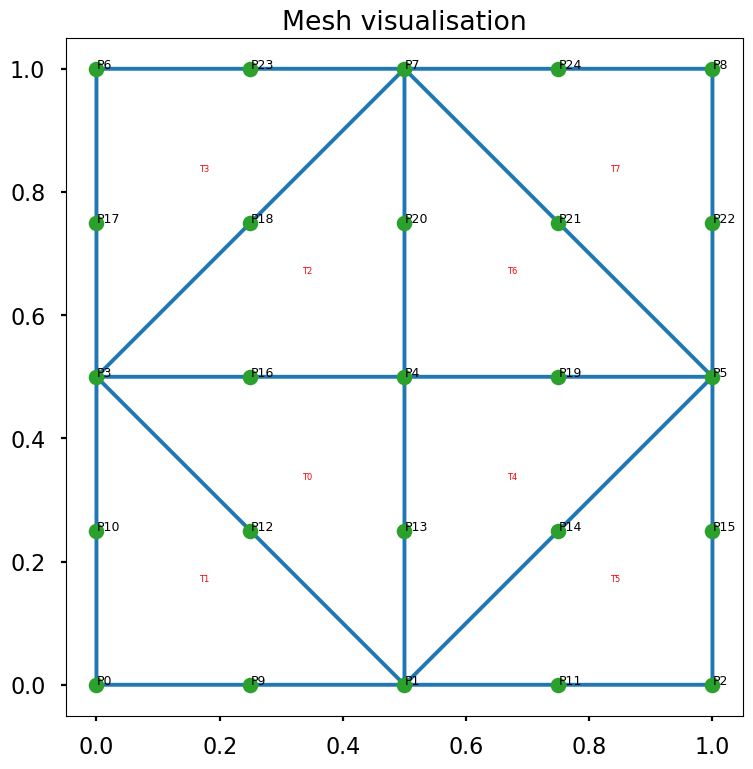

n_points=3: No degenerate pair found near 49.3480. Closest eigenvalue: 57.3111 at index 1 - skipping degenerate pair analysis


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Saved ./eigenfunction_mode1.png
Saved ./eigenfunction_mode2.png
Saved ./eigenfunction_mode3.png


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

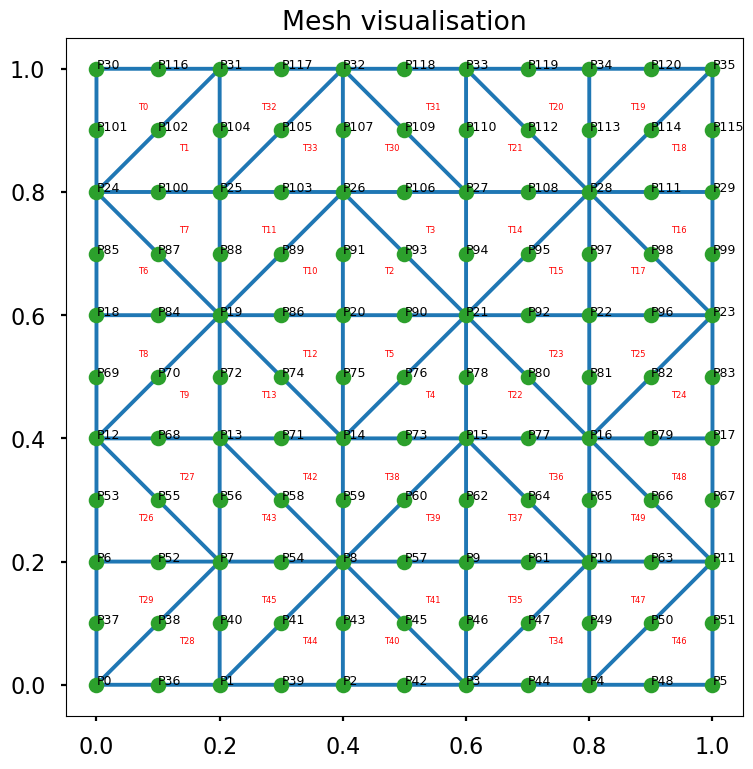

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Saved ./eigenfunction_mode1.png
Saved ./eigenfunction_mode2.png
Saved ./eigenfunction_mode3.png


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Degenerate mode 1: alpha=0.8872, beta=-0.4619 - numerical eigenvector is a rotation within the exact eigenspace.


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

...

Degenerate mode 1: alpha=-0.4226, beta=-0.9063 - numerical eigenvector is a rotation within the exact eigenspace.


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Degenerate mode 2: alpha=0.9063, beta=-0.4226 - numerical eigenvector is a rotation within the exact eigenspace.


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

##### SUMMARY #####

### EIGENVALUES ###

# FIRST EIGENVALUE #

ERROR DEPENDENCY ON THE NUMBER POINTS PER AXIS
   Points per axis  Interior DoF First eigenvalue     Error
1                3             9         19.94133  0.202126
2                6            81         19.76407  0.024864
3               12           441         19.74036  0.001153
4               24          2025         19.73927  0.000062
5               48          8649         19.73921  0.000004


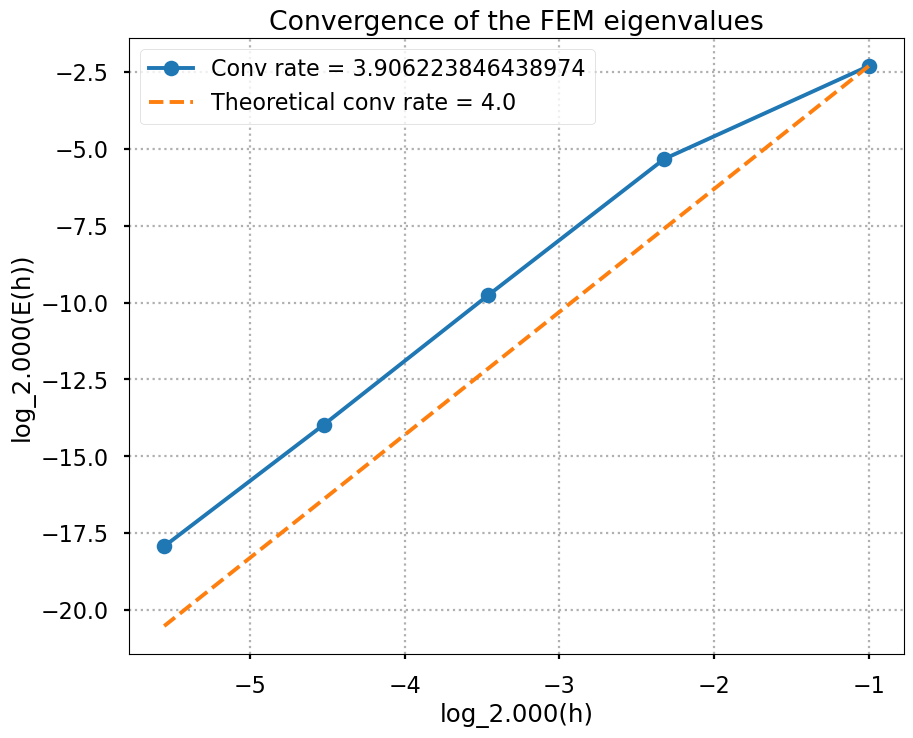


CONVERGENCE RATE TABLE
           h $\lambda_{1,h}$     Error  Rate of convergence
1  0.500000        19.94133  0.202126                  NaN
2  0.200000        19.76407  0.024864             3.023125
3  0.090909        19.74036  0.001153             4.430594
4  0.043478        19.73927  0.000062             4.216980
5  0.021277        19.73921  0.000004             3.954196

Global eigenvalue convergence rate: 3.906223846438974 (expected 4.0)

# DEGENERATE (REPEATED) EIGENVALUES #

ERROR DEPENDENCY ON THE NUMBER POINTS PER AXIS
   Points per axis  Interior DoF  Mean of Second and Third     Error
1              3.0           9.0                 57.311070  7.963048
2              6.0          81.0                 49.654797  0.306775
3             12.0         441.0                 49.363145  0.015123
4             24.0        2025.0                 49.348828  0.000806
5             48.0        8649.0                 49.348069  0.000046


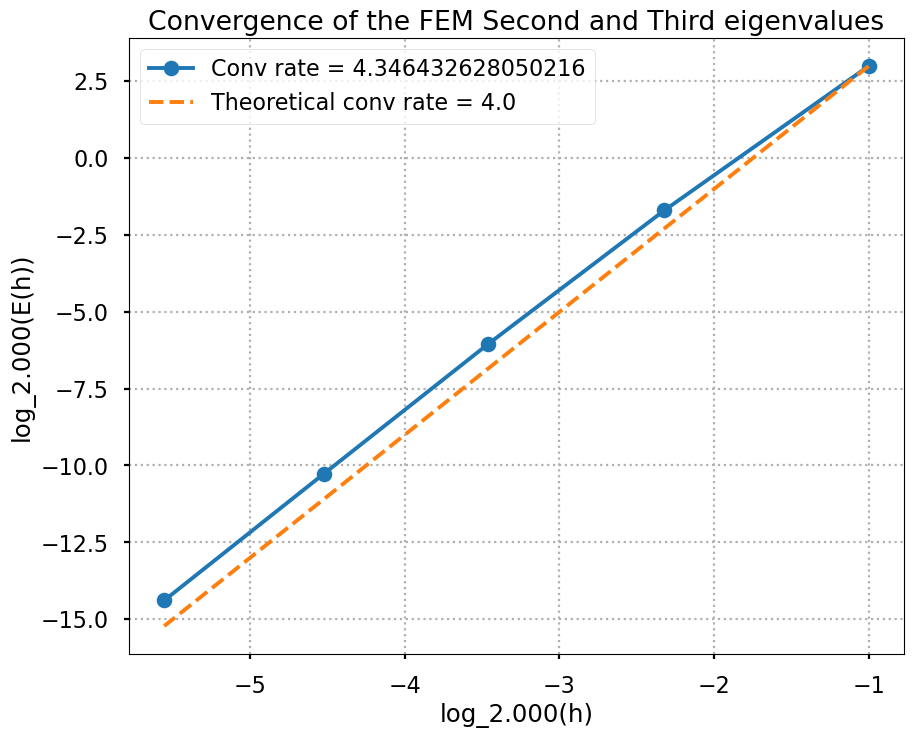


CONVERGENCE RATE TABLE
           h  $Mean of \lambda_{2,h} and \lambda_{3,h}$     Error  \
1  0.500000                                  57.311070  7.963048   
2  0.200000                                  49.654797  0.306775   
3  0.090909                                  49.363145  0.015123   
4  0.043478                                  49.348828  0.000806   
5  0.021277                                  49.348069  0.000046   

   Rate of convergence  
1                  NaN  
2             4.698070  
3             4.342315  
4             4.228974  
5             4.116372  

Global eigenvalue convergence rate: 4.346432628050216 (expected 4.0)

### EIGENFUNCTIONS ###

# NON-DEGENERATE (NON-REPEATED) EIGENFUCNTIONS #

L2 ERROR BETWEEN EXACT AND NUMERICAL EIGENFUNCTIONS
   Number of Elements     Error
1                 3.0  0.011323
2                 6.0  0.001789
3                12.0  0.000153
4                24.0  0.000016
5                48.0  0.000002

H1 ERROR BETWEEN EXACT AND

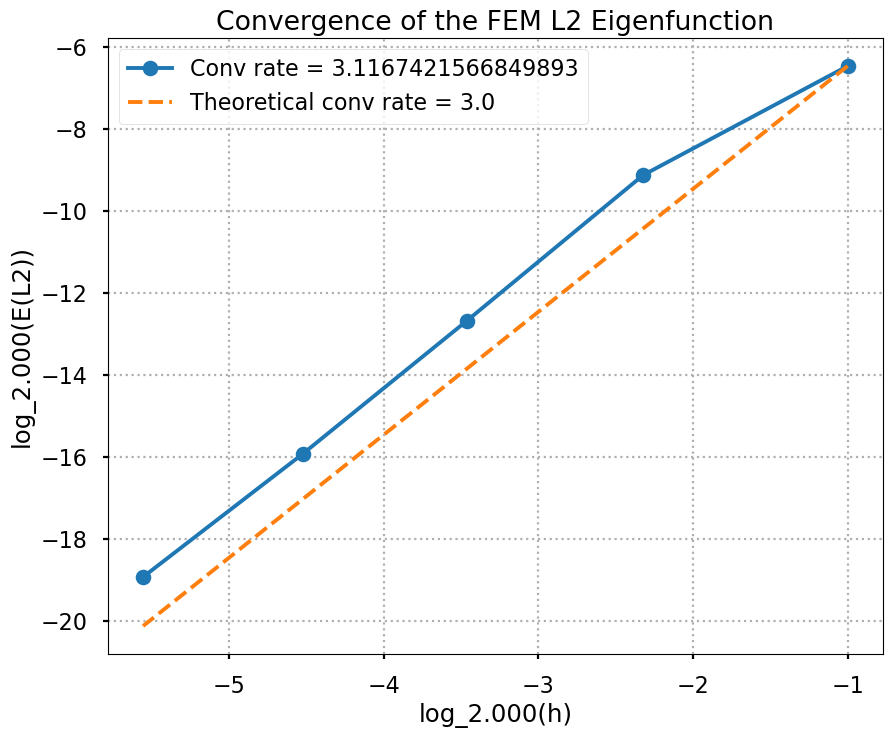

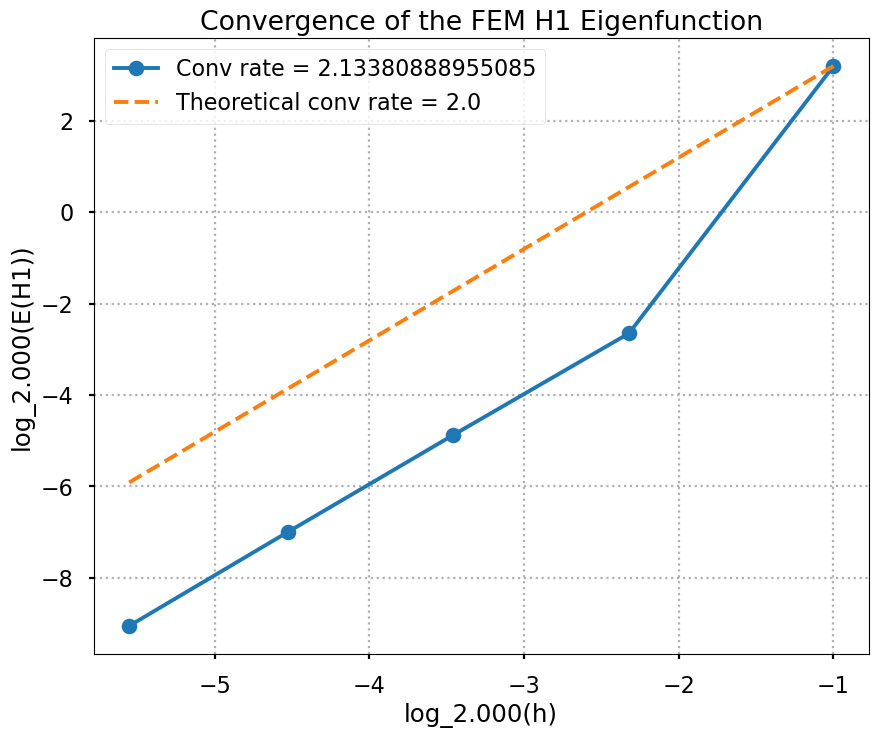


EIGENFUNCTION CONVERGENCE RATE TABLE (L2)
          h     Error  Rate of convergence
1  0.500000  0.011323                  NaN
2  0.200000  0.001789             2.662031
3  0.090909  0.000153             3.547550
4  0.043478  0.000016             3.257388
5  0.021277  0.000002             3.000000


EIGENFUNCTION CONVERGENCE RATE TABLE (H1)
          h     Error  Rate of convergence
1  0.500000  9.150693                  NaN
2  0.200000  0.159279             5.844255
3  0.090909  0.034025             2.226877
4  0.043478  0.007874             2.111350
5  0.021277  0.001884             2.063199


Global eigenfunction L2 convergence rate: 3.1167421566849893 (expected 3.0)

Global eigenfunction H1 convergence rate: 2.13380888955085 (expected 2.0)

# DEGENERATE (REPEATED) EIGENFUNCTIONS #

PROJECTION ERROR BETWEEN EXACT AND SECOND/THIRD NUMERICAL EIGENFUNCTIONS
   Number of Elements     Error
1                 3.0       NaN
2                 6.0  0.007687
3                12.0  0.000602


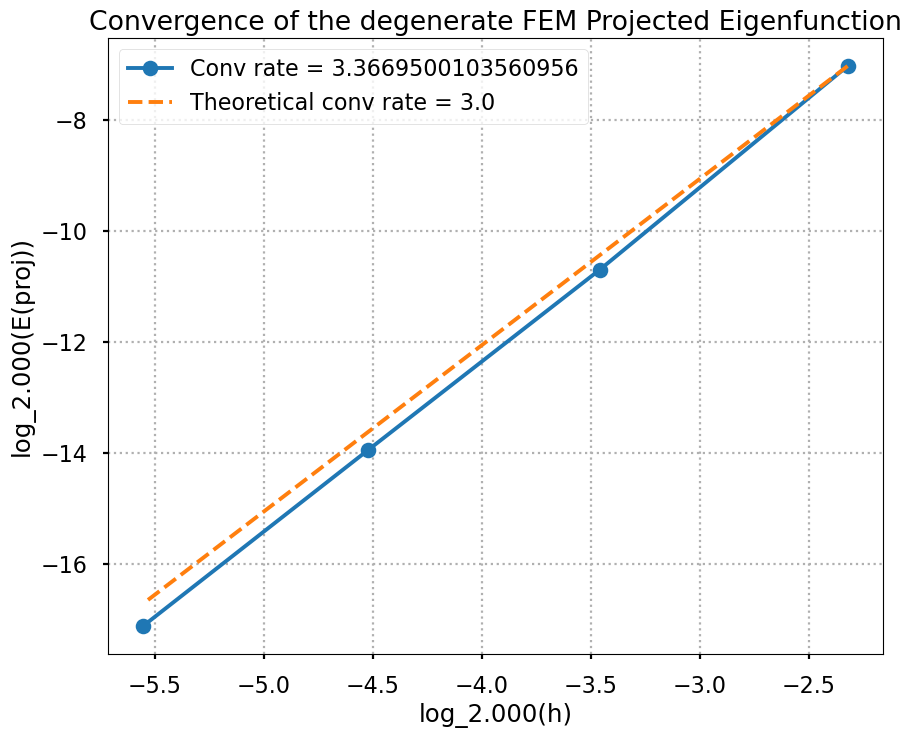

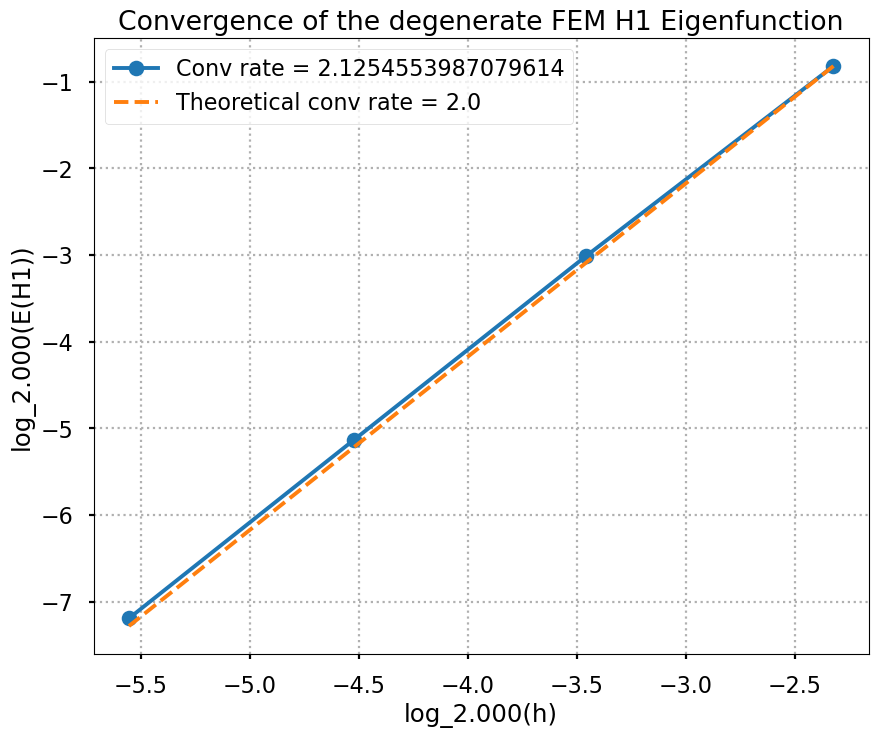


SECOND-THIRD EIGENFUNCTION CONVERGENCE RATE TABLE (Projection)
          h     Error  Rate of convergence
1  0.500000       NaN                  NaN
2  0.200000  0.007687                  NaN
3  0.090909  0.000602             3.674585
4  0.043478  0.000063             3.256340
5  0.021277  0.000007             3.169925


SECOND-THIRD EIGENFUNCTION CONVERGENCE RATE TABLE (H1)
          h     Error  Rate of convergence
1  0.500000       NaN                  NaN
2  0.200000  0.567328                  NaN
3  0.090909  0.123601             2.198500
4  0.043478  0.028430             2.120199
5  0.021277  0.006829             2.057668


Global eigenfunction projection convergence rate: 3.3669500103560956 (expected 3.0)

Global eigenfunction H1 convergence rate: 2.1254553987079614 (expected 2.0)


In [25]:
n_points_list = [3, 6, 12, 24, 48]

potential = 0


eigval_errors = []
eigval_23_errors = []
eigf_L2_errors = []
# projection errors of the second and third eigenvectors
eigf_23_proj_errors = []

# H1 errors
eigf_1_H1_errors = []
eigf_23_H1_errors = []

# we take quadrature of 6 points
quadrature_coords, weights = gaussian_quadrature_constants()

# derive basis functions
# a 6x1 matrix of basis functions on the reference triangle
B_phi = derive_p2_basis_func()
B_grad_phi = basis_func_grad(B_phi)

# will evaluate the sumpy matrix, like it evaluates the numpy matrix
grad_phi_func = sp.lambdify(
       (xi, eta),
       B_grad_phi,
       "numpy"
)

phi_func = sp.lambdify(
       (xi, eta),
       B_phi,
       "numpy"
)

# TABLES
# error table
error_table = pd.DataFrame(columns=["Points per axis", "Interior DoF", "First eigenvalue", "Error"])
error_23_table = pd.DataFrame(columns=["Points per axis", "Interior DoF", "Mean of Second and Third", "Error"])
# convergence rate table
conv_table = pd.DataFrame(columns=["h", r"$\lambda_{1,h}$", "Error", "Rate of convergence"])
conv_23_table = pd.DataFrame(columns=["h", r"$Mean of \lambda_{2,h} and \lambda_{3,h}$", "Error", "Rate of convergence"])
# eigenfunction error table
first_eigf_L2_error_table = pd.DataFrame(columns=["Number of Elements", "Error"])
first_eigf_H1_error_table = pd.DataFrame(columns=["Number of Elements", "Error"])

eigf_23_proj_error_table = pd.DataFrame(columns=("Number of Elements", "Error"))
eigf_23_H1_error_table = pd.DataFrame(columns=("Number of Elements", "Error"))
# eigenfunction convergence table
eigf_L2_conv_table = pd.DataFrame(columns=["h", "Error", "Rate of convergence"])
eigf_1_H1_conv_table = pd.DataFrame(columns=["h", "Error", "Rate of convergence"])

eigf_23_proj_conv_table = pd.DataFrame(columns=["h", "Error", "Rate of convergence"])
eigf_23_H1_conv_table = pd.DataFrame(columns=["h", "Error", "Rate of convergence"])


for index, n_points in enumerate(n_points_list):
       result = run_FEM_P2_analysis(n_points, index, quadrature_coords, weights, grad_phi_func, phi_func, potential=potential)
       #eigvals
       eigval_errors.append(result["1_eigval_error"])
       eigval_23_errors.append(np.mean(result["2,3_eigval_errors"]))
       # eigfunctions
       eigf_L2_errors.append(result["1_eigf_L2_error"])
       eigf_23_proj_errors.append(np.mean(result["2,3_eigf_proj_error"]))

       eigf_1_H1_errors.append(result["1_eigf_H1_error"])
       eigf_23_H1_errors.append(np.mean(result["2,3_eigf_H1_error"]))


       # put results in the table
       error_table.loc[index + 1] = [result["n_points"], result["dofs"], result["eigval"], result["1_eigval_error"]]
       error_23_table.loc[index + 1] = [result["n_points"], result["dofs"], np.mean(result["2,3_eigvals"]), np.mean(result["2,3_eigval_errors"])]
       
       first_eigf_L2_error_table.loc[index + 1] = [result["n_points"], result["1_eigf_L2_error"]]
       first_eigf_H1_error_table.loc[index + 1] = [result["n_points"], result["1_eigf_H1_error"]]
       

       eigf_23_proj_error_table.loc[index + 1] = [result["n_points"], np.mean(result["2,3_eigf_proj_error"])]
       eigf_23_H1_error_table.loc[index + 1] = [result["n_points"], np.mean(result["2,3_eigf_H1_error"])]
       
       
       ### Convergence
       p_eigval = local_convergence_rate(index, n_points_list, eigval_errors)
       p_23_eigval = local_convergence_rate(index, n_points_list, eigval_23_errors)

       p_L2_eigf = local_convergence_rate(index, n_points_list, eigf_L2_errors)
       p_23_proj_eigf = local_convergence_rate(index, n_points_list, eigf_23_proj_errors)

       p_1_H1 = local_convergence_rate(index, n_points_list, eigf_1_H1_errors)
       p_23_H1 = local_convergence_rate(index, n_points_list, eigf_23_H1_errors)

       # eigvals
       conv_table.loc[index + 1] = [result["h"], result["eigval"], result["1_eigval_error"], p_eigval]
       conv_23_table.loc[index + 1] = [result["h"], np.mean(result["2,3_eigvals"]), np.mean(result["2,3_eigval_errors"]), p_23_eigval]

       # eigfunc
       eigf_L2_conv_table.loc[index + 1] = [result["h"], result["1_eigf_L2_error"], p_L2_eigf]
       eigf_23_proj_conv_table.loc[index + 1] = [result["h"], np.mean(result["2,3_eigf_proj_error"]), p_23_proj_eigf]

       eigf_1_H1_conv_table.loc[index + 1] = [result["h"], result["1_eigf_H1_error"], p_1_H1]
       eigf_23_H1_conv_table.loc[index + 1] = [result["h"], np.mean(result["2,3_eigf_H1_error"]), p_23_H1]
       

ratio_between_num_points = [n_points_list[i] / n_points_list[i-1] for i in range(1, len(n_points_list))] 
base = np.mean(ratio_between_num_points)
hs = np.array(conv_table["h"].tolist())

eigval_errors = np.array(eigval_errors)
eigval_23_errors = np.array(eigval_23_errors)

eigf_L2_errors = np.array(eigf_L2_errors)
eigf_23_proj_errors = np.array(eigf_23_proj_errors)
eigf_1_H1_errors = np.array(eigf_1_H1_errors)
eigf_23_H1_errors = np.array(eigf_23_H1_errors)


### Global convergence rates
p_global_eigval = np.nanmean(conv_table["Rate of convergence"].tolist()[1:])
p_global_23_eigval = np.nanmean(conv_23_table["Rate of convergence"].tolist()[1:])
p_global_L2_eigf = np.nanmean(eigf_L2_conv_table["Rate of convergence"].tolist()[1:])
p_global_proj_23_eigf = np.nanmean(eigf_23_proj_conv_table["Rate of convergence"].tolist()[1:])
p_global_H1_1_eigf = np.nanmean(eigf_1_H1_conv_table["Rate of convergence"].tolist()[2:])
p_global_H1_23_eigf = np.nanmean(eigf_23_H1_conv_table["Rate of convergence"].tolist()[1:])

### SUMMARY
print("##### SUMMARY #####")
print()
### Eigenvalues
print("### EIGENVALUES ###")
print()

print("# FIRST EIGENVALUE #")
# Error table
print(f"\nERROR DEPENDENCY ON THE NUMBER POINTS PER AXIS\n{error_table}")

# log-log plot
plot_convergence(hs, eigval_errors, base, 4.0, "Convergence of the FEM eigenvalues", "(E(h))", p_global_eigval)

# Convergence rate
print(f"\nCONVERGENCE RATE TABLE\n {conv_table}")
print(f"\nGlobal eigenvalue convergence rate: {p_global_eigval} (expected 4.0)")

print()
print("# DEGENERATE (REPEATED) EIGENVALUES #")

# Error table
print(f"\nERROR DEPENDENCY ON THE NUMBER POINTS PER AXIS\n{error_23_table}")
# log-log plot
plot_convergence(hs, eigval_23_errors, base, 4.0, "Convergence of the FEM Second and Third eigenvalues", "(E(h))", p_global_23_eigval)

# Convergence rate
print(f"\nCONVERGENCE RATE TABLE\n {conv_23_table}")
print(f"\nGlobal eigenvalue convergence rate: {p_global_23_eigval} (expected 4.0)")

### Eigenfunctions
print()
print("### EIGENFUNCTIONS ###")
print()

## Non-degenerate
print("# NON-DEGENERATE (NON-REPEATED) EIGENFUCNTIONS #")
# Error between the exact and numerical eigenfunctions
print(f"\nL2 ERROR BETWEEN EXACT AND NUMERICAL EIGENFUNCTIONS\n{first_eigf_L2_error_table}")
print(f"\nH1 ERROR BETWEEN EXACT AND NUMERICAL EIGENFUNCTIONS\n{first_eigf_H1_error_table}")

plot_convergence(hs, eigf_L2_errors, base, 3.0, "Convergence of the FEM L2 Eigenfunction", "(E(L2))", p_global_L2_eigf)
plot_convergence(hs, eigf_1_H1_errors, base, 2.0, "Convergence of the FEM H1 Eigenfunction", "(E(H1))", p_global_H1_1_eigf)

# convergence rate of the eigenfucntions
print(f"\nEIGENFUNCTION CONVERGENCE RATE TABLE (L2)\n{eigf_L2_conv_table}\n")
print(f"\nEIGENFUNCTION CONVERGENCE RATE TABLE (H1)\n{eigf_1_H1_conv_table}\n")

print(f"\nGlobal eigenfunction L2 convergence rate: {p_global_L2_eigf} (expected 3.0)")
print(f"\nGlobal eigenfunction H1 convergence rate: {p_global_H1_1_eigf} (expected 2.0)")

print()
print("# DEGENERATE (REPEATED) EIGENFUNCTIONS #")

print(f"\nPROJECTION ERROR BETWEEN EXACT AND SECOND/THIRD NUMERICAL EIGENFUNCTIONS\n{eigf_23_proj_error_table}")
print(f"\nH1 ERROR BETWEEN EXACT AND SECOND/THIRD NUMERICAL EIGENFUNCTIONS\n{eigf_23_H1_error_table}")

# have to use hs[1:] and errors[1:] since the coarse mesh porduces nan in the error, because it doesnt have the degenerate eigenfunctions, therefore needs to be skipped
plot_convergence(hs[1:], eigf_23_proj_errors[1:], base, 3.0, "Convergence of the degenerate FEM Projected Eigenfunction", "(E(proj))", p_global_proj_23_eigf)
plot_convergence(hs[1:], eigf_23_H1_errors[1:], base, 2.0, "Convergence of the degenerate FEM H1 Eigenfunction", "(E(H1))", p_global_H1_23_eigf)


# convergence rate of the eigenfucntions
print(f"\nSECOND-THIRD EIGENFUNCTION CONVERGENCE RATE TABLE (Projection)\n{eigf_23_proj_conv_table}\n")
print(f"\nSECOND-THIRD EIGENFUNCTION CONVERGENCE RATE TABLE (H1)\n{eigf_23_H1_conv_table}\n")

print(f"\nGlobal eigenfunction projection convergence rate: {p_global_proj_23_eigf} (expected 3.0)")
print(f"\nGlobal eigenfunction H1 convergence rate: {p_global_H1_23_eigf} (expected 2.0)")


the projections are more mathematically meaningful, because solver may return different vectors, which would be both correct, but simply measuring the difference will give us bigger error, therefore we need to measure the projection on the eigenspace, in other words, how much the numerical solution "covers" the the exact function

mode (1,2), eigvec 2: |<u_h, f_exact>|_M = 0.969900
mode (2,1), eigvec 1: |<u_h, f_exact>|_M = 0.969900

both degenerate modes project onto different eigenvectors now, with projection approx 0.97. this tells us: "97% of this eigenvector's energy lies in the direction of the exact eigenfunction, the remaining 3% is the FEM approximation error" 
with mesh refinement this error will decrease

f1 = sin(πx)sin(2πy) and f2 = sin(2πx)sin(πy) are orthogonal in the continuous L2 inner product — you can verify this analytically. But your f1 and f2 are not continuous functions, they are vectors of pointwise evaluations at mesh nodes. The M-inner product f1 @ M @ f2 tells you whether they are also orthogonal in the discrete M-inner product on your specific mesh.
This matters because your projection formula assumes orthogonality

- for a vector u_h_norm that lies inside the eigenspace you'd expect alpha² + beta² = 1

- The coarsest mesh simply cannot see the 5π² eigenvalue. With n_points=3 you have 9 interior P2 nodes — that's not enough DOFs to resolve the second distinct eigenvalue of the Laplacian. The 57.31 you're seeing is not a numerical approximation to 49.35; it's a completely different mode that the coarse mesh is resolving first.
- The slight asymmetry in the Delaunay mesh is also why H1 degenerate errors weren't converging — you were feeding wrong eigenvector pairs. With the ValueError guard in place and starting from n_points=6, both the projection and H1 degenerate tables should now behave.

- One thing worth noting for your report: your H1 degenerate rate is computed from only three data points (rows 3-5) because n_points=3 is skipped and n_points=6 has no predecessor for a rate. That's fine mathematically, but a reader will notice the thin evidence. If you want a fourth point, you could add n_points=9 or n_points=10 to your list between 6 and 12 — it would resolve the degenerate pair and give you one more rate estimate.
- [Certain] The 9.15 H1 error at n_points=3 is not a bug and should stay in your table — it honestly reflects that a 9-DOF mesh cannot resolve the H1 seminorm of this eigenfunction. Just note it in your report as pre-asymptotic behaviour rather than hiding it.

# Schrodinger
for schrodinger equation we need to use the potential energy value in comparison to the laplace

When the V is constant we can adjust the error check by shifting it by the size of the constant that our potential energy is, but is we use something more complicated, for example harmonic oscillator it will:
1) require a 12 point quadrature rule because the previous 6-point one exact only to degree 4, while we will get the polynomial of degree <=6. and 

2) The exact_eigenvalue(m, n) + potential trick only worked because a constant V doesn't change eigenfunctions, only shifts eigenvalues by a known amount. A spatially varying V changes the eigenfunctions themselves — there's no closed form on your bounded unit square for the harmonic oscillator. If you want to sanity-check against the textbook QM spectrum (n_x + n_y + 1, in natural units), that only holds in the limit of an infinite domain; on your finite square, the hard Dirichlet wall at the boundary introduces its own error relative to that spectrum, separate from your FEM discretization error, and it only vanishes if your domain is large compared to the oscillator's characteristic width. Getting a "wrong" first eigenvalue against the textbook number doesn't necessarily mean your code is broken — it may mean your box isn't big enough. Your fallback for validation without a domain-size confound: Richardson-extrapolate a very fine mesh as a proxy "exact" value and check convergence toward that, the same role your closed form played before.

# Important 
for a genuinely polynomial V like harmonic oscillator, you can make quadrature error exactly zero by choosing a high enough order — but the moment you move to a non-polynomial V (Coulomb, anything with 1/r or exp), no finite quadrature rule is ever exact, and you'll need to pick an order high enough that the residual quadrature error sits well below whatever discretization error you're trying to measure across your whole h-range. That's a permanent modeling decision from then on, not a one-time fix.